
Device: mps

Ground truth — FH102_02:
  Positive (bird)  : 33
  Negative (normal): 925

───────────────────────────────────────────────────────
  STEP 1 — Loading datasets
───────────────────────────────────────────────────────
Dataset loaded: 21593 frames  [raw mode]
Dataset loaded: 21593 frames  [diff mode]

───────────────────────────────────────────────────────
  STEP 2 — Training Model A (raw frames)
───────────────────────────────────────────────────────

  TRAINING: model_A_raw


  Epoch [1/10]  Loss: 0.0770


  Epoch [2/10]  Loss: 0.0134


  Epoch [3/10]  Loss: 0.0086


  Epoch [4/10]  Loss: 0.0069


...

  Epoch [8/10]  Loss: 0.0023


  Epoch [9/10]  Loss: 0.0021


  Epoch [10/10]  Loss: 0.0021
  Model saved: /Users/iris/Desktop/ETH/DAS Project/camera-trap-gan/outputs/dual_model_20260315_151948/model_B_diff_final.pth

───────────────────────────────────────────────────────
  STEP 4 — Scoring all frames
───────────────────────────────────────────────────────


  Scoring diff: 100%|██████████| 675/675 [05:59<00:00,  1.88it/s]



  Smoothing diff scores (window=2)...
  Normalising and combining scores...
  Weights: raw=0.5  diff=0.5
  Raw   scores: mean=0.0038  std=0.0029
  Diff  scores: mean=0.0019  std=0.0033
  Combined    : mean=0.0312  std=0.0305

───────────────────────────────────────────────────────
  STEP 7 — Evaluation
───────────────────────────────────────────────────────

  RESULTS — Model A — Raw  [FH102_02]
  Total frames        :  21,593
  Labelled frames     :     958  (4.4% of total)
  Unlabelled frames   :  20,635
  Bird frames         :      33
  Normal frames       :     925

  ── ALL frames (total detection scope) ─────────
  Total flagged       :     887  (4.1% of all frames)
  Not flagged         :  20,706  (95.9% of all frames)
  Flagged labelled    :     352  (36.7% of labelled)
  Flagged unlabelled  :     535  (2.6% of unlabelled)

  ── LABELLED frames (evaluation subset) ────────
  AUC-ROC             :   0.818  ← main metric
  Avg Precision       :   0.131
  Precision           :   

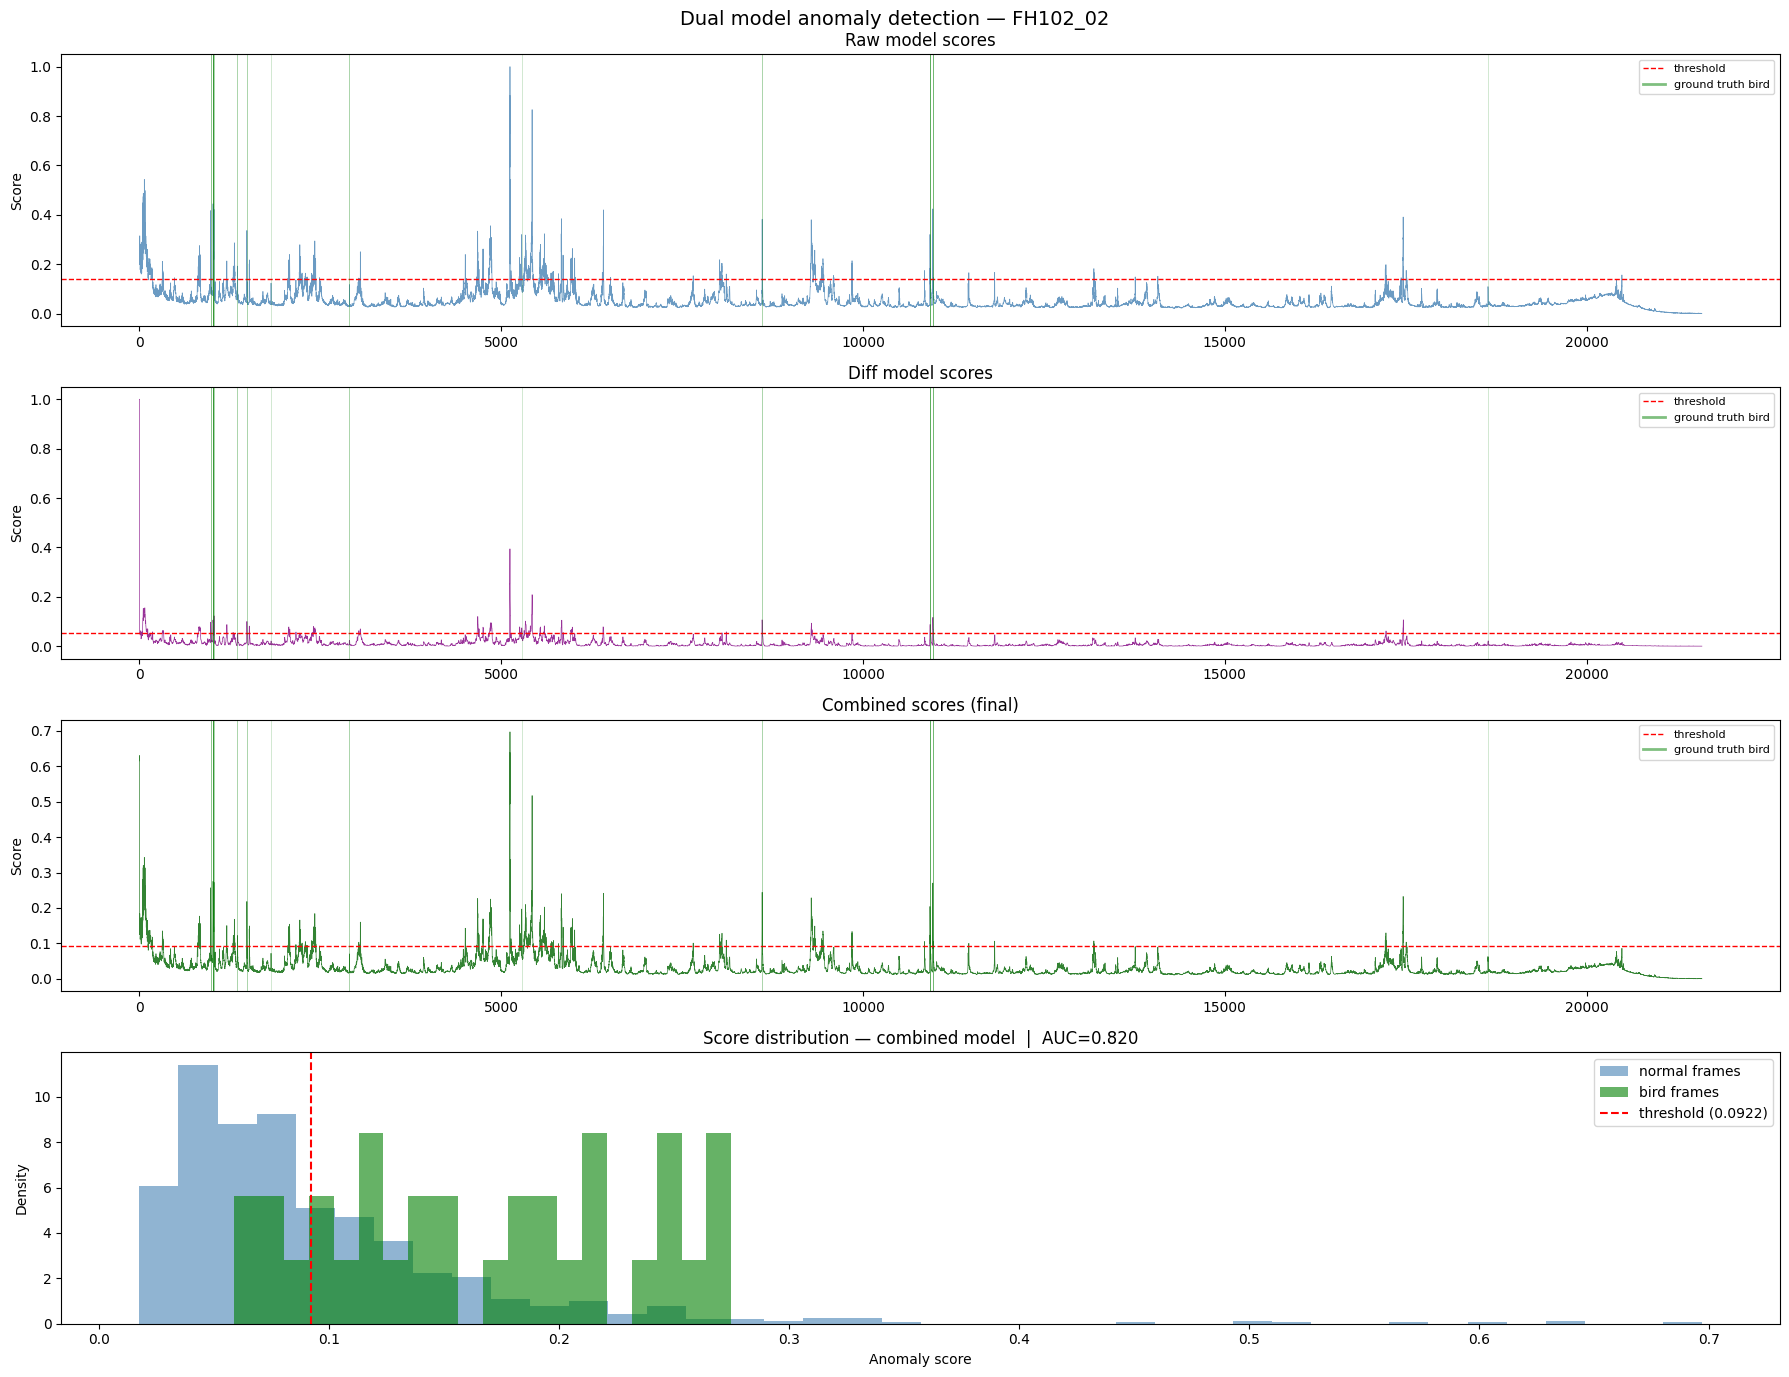


Plot saved: /Users/iris/Desktop/ETH/DAS Project/camera-trap-gan/outputs/dual_model_20260315_151948/dual_model_results.png

───────────────────────────────────────────────────────
  STEP 10 — Saving suspicious frames
───────────────────────────────────────────────────────
  877 frames saved to suspicious_combined/
  BIRD  : 28
  normal: 849

All outputs saved to:
  /Users/iris/Desktop/ETH/DAS Project/camera-trap-gan/outputs/dual_model_20260315_151948


In [2]:
"""
Dual Model Anomaly Detection Pipeline
======================================
Trains two separate autoencoders:
  Model A — trained on raw frames     → detects presence anomalies
  Model B — trained on diff frames    → detects motion anomalies

Combines their scores with smoothing to handle:
  - Bird sitting still (frame 11 problem) → raw model catches it
  - Bird appearing/disappearing          → diff model catches it
  - Lighting / wind false positives      → diff model ignores them

Usage:
  python dual_model_pipeline.py
"""

import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import os
import shutil
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.metrics import (roc_auc_score, precision_recall_fscore_support,
                             confusion_matrix, average_precision_score)
from tqdm import tqdm
from datetime import datetime
import cv2

# ══════════════════════════════════════════════════════════════
# CONFIG
# ══════════════════════════════════════════════════════════════
FRAMES_FOLDER  = "/Users/iris/Desktop/ETH/DAS Project/camera-trap-gan/data/frames/FH102_02"
CSV_PATH       = "/Users/iris/Desktop/ETH/DAS Project/camera-trap-gan/data/Weinstein2018MEE_ground_truth.csv"
VIDEO_NAME     = "FH102_02"
IMG_SIZE       = 256
BATCH_SIZE     = 32
EPOCHS         = 10
LEARNING_RATE  = 0.001
LATENT_DIM     = 256      # try 256 first, then 128
THRESHOLD_STD  = 2
SMOOTH_WINDOW  = 2        # frames to look ahead/behind for smoothing
WEIGHT_RAW     = 0.5      # weight for raw model score
WEIGHT_DIFF    = 0.5      # weight for diff model score
TIMESTAMP      = datetime.now().strftime("%Y%m%d_%H%M%S")
OUTPUT_FOLDER  = f"/Users/iris/Desktop/ETH/DAS Project/camera-trap-gan/outputs/dual_model_{TIMESTAMP}"
# ══════════════════════════════════════════════════════════════


# ── Dataset ───────────────────────────────────────────────────
class CameraTrapDataset(Dataset):
    """
    Loads camera trap frames as either:
      use_diff=False  →  raw frame (standard autoencoder input)
      use_diff=True   →  absolute difference between frame t and t-1
                         (motion signal — near zero for static background)
    """
    def __init__(self, frames_folder, img_size=256, use_diff=False):
        self.frames_folder = frames_folder
        self.use_diff      = use_diff
        self.frame_paths   = sorted([
            os.path.join(frames_folder, f)
            for f in os.listdir(frames_folder)
            if f.endswith('.jpg')
        ])
        self.transform = transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
        ])
        mode = "diff" if use_diff else "raw"
        print(f"Dataset loaded: {len(self.frame_paths)} frames  [{mode} mode]")

    def __len__(self):
        return len(self.frame_paths)

    def __getitem__(self, idx):
        if self.use_diff and idx > 0:
            curr = cv2.imread(self.frame_paths[idx])
            prev = cv2.imread(self.frame_paths[idx - 1])
            curr = cv2.cvtColor(curr, cv2.COLOR_BGR2RGB)
            prev = cv2.cvtColor(prev, cv2.COLOR_BGR2RGB)
            img  = cv2.absdiff(curr, prev)
        else:
            img = cv2.imread(self.frame_paths[idx])
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        return self.transform(img), self.frame_paths[idx]


# ── Model ─────────────────────────────────────────────────────
class Autoencoder(nn.Module):
    """
    Convolutional autoencoder.
    Encodes frame to latent vector then reconstructs.
    Anomaly score = mean squared reconstruction error per frame.
    """
    def __init__(self, latent_dim=256):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 64,  kernel_size=4, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.Conv2d(256, 512, kernel_size=4, stride=2, padding=1), nn.BatchNorm2d(512), nn.ReLU(),
            nn.Flatten(),
            nn.Linear(512 * 16 * 16, latent_dim)
        )
        self.decoder_fc = nn.Linear(latent_dim, 512 * 16 * 16)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(512, 256, kernel_size=4, stride=2, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.ConvTranspose2d(128, 64,  kernel_size=4, stride=2, padding=1), nn.BatchNorm2d(64),  nn.ReLU(),
            nn.ConvTranspose2d(64,  3,   kernel_size=4, stride=2, padding=1), nn.Tanh()
        )

    def forward(self, x):
        z = self.encoder(x)
        x = self.decoder_fc(z)
        x = x.view(-1, 512, 16, 16)
        return self.decoder(x)

    def anomaly_score(self, x):
        return torch.mean((x - self.forward(x)) ** 2, dim=[1, 2, 3])


# ── Train one model ───────────────────────────────────────────
def train_model(dataset, device, model_name, latent_dim=256):
    """Train a single autoencoder and return the trained model."""

    print(f"\n{'='*55}")
    print(f"  TRAINING: {model_name}")
    print(f"{'='*55}")

    loader    = DataLoader(dataset, batch_size=BATCH_SIZE,
                           shuffle=True, num_workers=0)
    model     = Autoencoder(latent_dim=latent_dim).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    criterion = nn.MSELoss()
    losses    = []

    for epoch in range(EPOCHS):
        model.train()
        epoch_loss = 0

        for frames, _ in tqdm(loader,
                              desc=f"  Epoch {epoch+1}/{EPOCHS}",
                              leave=False):
            frames = frames.to(device)
            optimizer.zero_grad()
            loss = criterion(model(frames), frames)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        epoch_loss /= len(loader)
        losses.append(epoch_loss)
        print(f"  Epoch [{epoch+1}/{EPOCHS}]  Loss: {epoch_loss:.4f}")

        # checkpoint every 5 epochs
        if (epoch + 1) % 5 == 0:
            ckpt_path = os.path.join(OUTPUT_FOLDER,
                                     f"{model_name}_epoch{epoch+1}.pth")
            torch.save(model.state_dict(), ckpt_path)

    # save final model
    final_path = os.path.join(OUTPUT_FOLDER, f"{model_name}_final.pth")
    torch.save(model.state_dict(), final_path)
    print(f"  Model saved: {final_path}")

    # save loss curve
    plt.figure(figsize=(8, 3))
    plt.plot(losses, linewidth=2)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Training loss — {model_name}")
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_FOLDER, f"{model_name}_loss.png"))
    plt.close()

    return model, losses


# ── Score all frames ──────────────────────────────────────────
def score_frames(model, dataset, device, desc="Scoring"):
    """Run detection on all frames in time order. Returns scores + paths."""

    loader     = DataLoader(dataset, batch_size=BATCH_SIZE,
                            shuffle=False, num_workers=0)
    all_scores = []
    all_paths  = []

    model.eval()
    with torch.no_grad():
        for frames, paths in tqdm(loader, desc=f"  {desc}"):
            frames = frames.to(device)
            scores = model.anomaly_score(frames)
            all_scores.extend(scores.cpu().numpy())
            all_paths.extend(paths)

    return np.array(all_scores), all_paths


# ── Smooth scores ─────────────────────────────────────────────
def smooth_max(scores, window=2):
    """
    For each frame take the max score in a window around it.
    Fixes the frame-11 problem: if bird sits still between frames
    10 and 11, frame 11 inherits the high score from frame 10/12.
    """
    smoothed = np.zeros_like(scores)
    for i in range(len(scores)):
        start        = max(0, i - window)
        end          = min(len(scores), i + window + 1)
        smoothed[i]  = np.max(scores[start:end])
    return smoothed


# ── Normalise to [0,1] ────────────────────────────────────────
def normalise(scores):
    mn = scores.min()
    mx = scores.max()
    return (scores - mn) / (mx - mn + 1e-8)


# ── Load ground truth ─────────────────────────────────────────
def load_ground_truth(csv_path, video_name):
    df       = pd.read_csv(csv_path)
    df_video = df[df['Video'] == video_name].copy()

    positive_frames = set(
        f"frame_{(row['Frame'] - 1):05d}.jpg"
        for _, row in df_video.iterrows()
        if row['Truth'] == 'Positive'
    )
    negative_frames = set(
        f"frame_{(row['Frame'] - 1):05d}.jpg"
        for _, row in df_video.iterrows()
        if row['Truth'] == 'Negative'
    )

    print(f"\nGround truth — {video_name}:")
    print(f"  Positive (bird)  : {len(positive_frames)}")
    print(f"  Negative (normal): {len(negative_frames)}")

    return positive_frames, negative_frames


# ── Evaluate ──────────────────────────────────────────────────
def evaluate(scores, all_paths, positive_frames, negative_frames,
             model_label="Model"):
    """
    Full evaluation:
      - Overall flagging stats (all frames)
      - Metrics on labelled frames only
      - Labelling bias analysis
      - Practical deployment metrics
    """
    threshold = scores.mean() + THRESHOLD_STD * scores.std()

    # categorise frames
    labelled_indices   = []
    unlabelled_indices = []
    y_true             = []
    y_pred             = []

    for i, (score, path) in enumerate(zip(scores, all_paths)):
        filename   = os.path.basename(path)
        is_flagged = 1 if score > threshold else 0

        if filename in positive_frames:
            labelled_indices.append(i)
            y_true.append(1)
            y_pred.append(is_flagged)
        elif filename in negative_frames:
            labelled_indices.append(i)
            y_true.append(0)
            y_pred.append(is_flagged)
        else:
            unlabelled_indices.append(i)

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # metrics on labelled frames
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='binary', zero_division=0)
    cm  = confusion_matrix(y_true, y_pred)
    auc = roc_auc_score(y_true, [scores[i] for i in labelled_indices])
    ap  = average_precision_score(y_true, [scores[i] for i in labelled_indices])

    # total flagging across ALL frames
    total_flagged          = int((scores > threshold).sum())
    flagged_unlabelled     = sum(1 for i in unlabelled_indices
                                 if scores[i] > threshold)
    total_flag_rate        = total_flagged / len(all_paths)
    labelled_flag_rate     = y_pred.sum() / len(y_true)

    # practical deployment
    birds_found            = int(y_true[y_pred == 1].sum())
    workload_reduction     = 1 - total_flag_rate

    print(f"\n{'='*58}")
    print(f"  RESULTS — {model_label}  [{VIDEO_NAME}]")
    print(f"{'='*58}")
    print(f"  Total frames        : {len(all_paths):>7,}")
    print(f"  Labelled frames     : {len(y_true):>7,}  ({len(y_true)/len(all_paths):.1%} of total)")
    print(f"  Unlabelled frames   : {len(unlabelled_indices):>7,}")
    print(f"  Bird frames         : {int(y_true.sum()):>7,}")
    print(f"  Normal frames       : {int((y_true==0).sum()):>7,}")
    print(f"")
    print(f"  ── ALL frames (total detection scope) ─────────")
    print(f"  Total flagged       : {total_flagged:>7,}  ({total_flag_rate:.1%} of all frames)")
    print(f"  Not flagged         : {len(all_paths)-total_flagged:>7,}  ({1-total_flag_rate:.1%} of all frames)")
    print(f"  Flagged labelled    : {int(y_pred.sum()):>7,}  ({labelled_flag_rate:.1%} of labelled)")
    print(f"  Flagged unlabelled  : {flagged_unlabelled:>7,}  ({flagged_unlabelled/len(unlabelled_indices):.1%} of unlabelled)")
    print(f"")
    print(f"  ── LABELLED frames (evaluation subset) ────────")
    print(f"  AUC-ROC             : {auc:>7.3f}  ← main metric")
    print(f"  Avg Precision       : {ap:>7.3f}")
    print(f"  Precision           : {precision:>7.3f}")
    print(f"  Recall              : {recall:>7.3f}")
    print(f"  F1 score            : {f1:>7.3f}")
    print(f"  Threshold           : {threshold:>7.4f}  (mean + {THRESHOLD_STD}×std)")
    print(f"")
    print(f"  ── Confusion matrix (labelled only) ────────────")
    print(f"                    Predicted")
    print(f"                    Normal    Bird")
    print(f"  Actual Normal   {cm[0][0]:>8,}  {cm[0][1]:>6,}")
    print(f"  Actual Bird     {cm[1][0]:>8,}  {cm[1][1]:>6,}")
    print(f"")
    print(f"  ── Flagging rate analysis ──────────────────────")
    print(f"  Total flag rate     : {total_flag_rate:.1%}")
    print(f"  Labelled flag rate  : {labelled_flag_rate:.1%}")
    print(f"  Bias ratio          : {labelled_flag_rate/total_flag_rate:.1f}x  (labelled set biased towards anomalies)")
    print(f"")
    print(f"  ── Practical deployment metrics ────────────────")
    print(f"  Without model: check all {len(all_paths):,} frames manually")
    print(f"  With model   : check only {total_flagged:,} frames  ({total_flag_rate:.1%})")
    print(f"  Workload reduction : {workload_reduction:.1%} fewer frames to check")
    print(f"  Birds found        : {birds_found} / {int(y_true.sum())}  (recall {recall:.1%})")
    print(f"{'='*58}")

    return {
        'auc': auc, 'ap': ap, 'precision': precision,
        'recall': recall, 'f1': f1,
        'total_flagged': total_flagged, 'total_flag_rate': total_flag_rate,
        'labelled_flag_rate': labelled_flag_rate,
        'workload_reduction': workload_reduction,
        'birds_found': birds_found, 'threshold': threshold,
        'y_true': y_true, 'y_pred': y_pred,
        'labelled_indices': labelled_indices,
    }


# ── Plot results ──────────────────────────────────────────────
def plot_results(scores_raw, scores_diff, scores_combined,
                 all_paths, positive_frames, results, title):
    """4-panel results plot."""

    bird_indices = [i for i, p in enumerate(all_paths)
                    if os.path.basename(p) in positive_frames]

    fig, axes = plt.subplots(4, 1, figsize=(18, 14))
    fig.suptitle(f"Dual model anomaly detection — {VIDEO_NAME}", fontsize=14)

    threshold = results['threshold']

    for ax, scores, label, color in [
        (axes[0], scores_raw,      "Raw model scores",      "steelblue"),
        (axes[1], scores_diff,     "Diff model scores",     "purple"),
        (axes[2], scores_combined, "Combined scores (final)", "darkgreen"),
    ]:
        ax.plot(scores, linewidth=0.5, color=color, alpha=0.8)
        ax.axhline(y=threshold if ax == axes[2] else
                   scores.mean() + THRESHOLD_STD * scores.std(),
                   color='red', linestyle='--', linewidth=1,
                   label='threshold')
        for idx in bird_indices:
            ax.axvline(x=idx, color='green', alpha=0.25, linewidth=0.5)
        ax.plot([], [], color='green', alpha=0.5,
                linewidth=2, label='ground truth bird')
        ax.set_title(label)
        ax.set_ylabel("Score")
        ax.legend(loc='upper right', fontsize=8)

    # histogram comparison
    ax = axes[3]
    y_true = results['y_true']
    scores_labelled = scores_combined[results['labelled_indices']]
    ax.hist(scores_labelled[y_true == 0], bins=40, alpha=0.6,
            color='steelblue', label='normal frames', density=True)
    ax.hist(scores_labelled[y_true == 1], bins=20, alpha=0.6,
            color='green', label='bird frames', density=True)
    ax.axvline(x=results['threshold'], color='red', linestyle='--',
               linewidth=1.5, label=f'threshold ({results["threshold"]:.4f})')
    ax.set_title(f"Score distribution — combined model  |  AUC={results['auc']:.3f}")
    ax.set_xlabel("Anomaly score")
    ax.set_ylabel("Density")
    ax.legend()

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_FOLDER, "dual_model_results.png"), dpi=150)
    plt.show()
    print(f"\nPlot saved: {OUTPUT_FOLDER}/dual_model_results.png")


# ── Save suspicious frames ────────────────────────────────────
def save_suspicious(scores, all_paths, positive_frames, threshold, label):
    """Save all frames above threshold, labelled BIRD or normal."""
    folder = os.path.join(OUTPUT_FOLDER, f"suspicious_{label}")
    os.makedirs(folder, exist_ok=True)

    flagged = [(s, p) for s, p in zip(scores, all_paths) if s > threshold]
    ranked  = sorted(flagged, reverse=True)

    for i, (score, path) in enumerate(ranked):
        filename = os.path.basename(path)
        is_bird  = "BIRD" if filename in positive_frames else "normal"
        dest     = os.path.join(folder,
                   f"rank{i+1:04d}_{is_bird}_{score:.4f}_{filename}")
        shutil.copy(path, dest)

    print(f"  {len(ranked)} frames saved to suspicious_{label}/")
    print(f"  BIRD  : {sum(1 for s,p in ranked if os.path.basename(p) in positive_frames)}")
    print(f"  normal: {sum(1 for s,p in ranked if os.path.basename(p) not in positive_frames)}")


# ── Comparison table ──────────────────────────────────────────
def print_comparison(results_dict):
    print(f"\n{'='*70}")
    print(f"  MODEL COMPARISON SUMMARY")
    print(f"{'='*70}")
    print(f"  {'Model':<20} {'AUC':>6} {'Prec':>6} {'Recall':>7} {'F1':>6} {'Flagged':>8} {'Workload↓':>10}")
    print(f"  {'-'*64}")
    for name, r in results_dict.items():
        print(f"  {name:<20} {r['auc']:>6.3f} {r['precision']:>6.3f} "
              f"{r['recall']:>7.3f} {r['f1']:>6.3f} "
              f"{r['total_flagged']:>8,} {r['workload_reduction']:>9.1%}")
    print(f"{'='*70}")


# ══════════════════════════════════════════════════════════════
# MAIN
# ══════════════════════════════════════════════════════════════
def main():
    os.makedirs(OUTPUT_FOLDER, exist_ok=True)

    # save config
    with open(os.path.join(OUTPUT_FOLDER, "config.txt"), "w") as f:
        f.write(f"""
Dual Model Pipeline
===================
Timestamp     : {TIMESTAMP}
Video         : {VIDEO_NAME}
Frames folder : {FRAMES_FOLDER}
Latent dim    : {LATENT_DIM}
Epochs        : {EPOCHS}
Batch size    : {BATCH_SIZE}
Learning rate : {LEARNING_RATE}
Threshold std : {THRESHOLD_STD}
Smooth window : {SMOOTH_WINDOW}
Weight raw    : {WEIGHT_RAW}
Weight diff   : {WEIGHT_DIFF}
""")

    # device
    device = torch.device(
        "mps"  if torch.backends.mps.is_available() else
        "cuda" if torch.cuda.is_available() else "cpu"
    )
    print(f"\nDevice: {device}")

    # ground truth
    positive_frames, negative_frames = load_ground_truth(CSV_PATH, VIDEO_NAME)

    # ── Step 1: create datasets ───────────────────────────────
    print(f"\n{'─'*55}")
    print(f"  STEP 1 — Loading datasets")
    print(f"{'─'*55}")
    dataset_raw  = CameraTrapDataset(FRAMES_FOLDER, IMG_SIZE, use_diff=False)
    dataset_diff = CameraTrapDataset(FRAMES_FOLDER, IMG_SIZE, use_diff=True)

    # ── Step 2: train Model A (raw) ───────────────────────────
    print(f"\n{'─'*55}")
    print(f"  STEP 2 — Training Model A (raw frames)")
    print(f"{'─'*55}")
    model_raw, losses_raw = train_model(
        dataset_raw, device, "model_A_raw", LATENT_DIM)

    # ── Step 3: train Model B (diff) ─────────────────────────
    print(f"\n{'─'*55}")
    print(f"  STEP 3 — Training Model B (diff frames)")
    print(f"{'─'*55}")
    model_diff, losses_diff = train_model(
        dataset_diff, device, "model_B_diff", LATENT_DIM)

    # ── Step 4: score all frames ──────────────────────────────
    print(f"\n{'─'*55}")
    print(f"  STEP 4 — Scoring all frames")
    print(f"{'─'*55}")
    scores_raw,  all_paths = score_frames(model_raw,  dataset_raw,  device, "Scoring raw")
    scores_diff, _         = score_frames(model_diff, dataset_diff, device, "Scoring diff")

    # ── Step 5: smooth diff scores ────────────────────────────
    print(f"\n  Smoothing diff scores (window={SMOOTH_WINDOW})...")
    scores_diff_smooth = smooth_max(scores_diff, window=SMOOTH_WINDOW)

    # ── Step 6: normalise + combine ───────────────────────────
    print(f"  Normalising and combining scores...")
    scores_raw_norm   = normalise(scores_raw)
    scores_diff_norm  = normalise(scores_diff_smooth)
    scores_combined   = WEIGHT_RAW * scores_raw_norm + WEIGHT_DIFF * scores_diff_norm

    print(f"  Weights: raw={WEIGHT_RAW}  diff={WEIGHT_DIFF}")
    print(f"  Raw   scores: mean={scores_raw.mean():.4f}  std={scores_raw.std():.4f}")
    print(f"  Diff  scores: mean={scores_diff.mean():.4f}  std={scores_diff.std():.4f}")
    print(f"  Combined    : mean={scores_combined.mean():.4f}  std={scores_combined.std():.4f}")

    # ── Step 7: evaluate all three ───────────────────────────
    print(f"\n{'─'*55}")
    print(f"  STEP 7 — Evaluation")
    print(f"{'─'*55}")

    results_raw      = evaluate(scores_raw,      all_paths, positive_frames, negative_frames, "Model A — Raw")
    results_diff     = evaluate(scores_diff_smooth, all_paths, positive_frames, negative_frames, "Model B — Diff (smoothed)")
    results_combined = evaluate(scores_combined, all_paths, positive_frames, negative_frames, "Combined (A+B)")

    # ── Step 8: comparison table ──────────────────────────────
    print_comparison({
        "Model A — Raw"      : results_raw,
        "Model B — Diff"     : results_diff,
        "Combined (A+B)"     : results_combined,
    })

    # ── Step 9: plot ──────────────────────────────────────────
    print(f"\n{'─'*55}")
    print(f"  STEP 9 — Plotting results")
    print(f"{'─'*55}")
    plot_results(scores_raw_norm, scores_diff_norm, scores_combined,
                 all_paths, positive_frames, results_combined,
                 "Combined model")

    # ── Step 10: save suspicious frames ──────────────────────
    print(f"\n{'─'*55}")
    print(f"  STEP 10 — Saving suspicious frames")
    print(f"{'─'*55}")
    save_suspicious(scores_combined, all_paths, positive_frames,
                    results_combined['threshold'], "combined")

    # open output folder
    os.system(f"open '{OUTPUT_FOLDER}'")
    print(f"\nAll outputs saved to:\n  {OUTPUT_FOLDER}")


if __name__ == "__main__":
    main()

Device: mps
Birds: 33  Normal: 925

Loading saved models...
  ✓ Model A loaded: /Users/iris/Desktop/ETH/DAS Project/camera-trap-gan/outputs/dual_model_20260315_151948/model_A_raw_final.pth
  ✓ Model B loaded: /Users/iris/Desktop/ETH/DAS Project/camera-trap-gan/outputs/dual_model_20260315_151948/model_B_diff_final.pth

Scoring all frames...
Dataset: 21593 frames  [raw mode]
Dataset: 21593 frames  [diff mode]


  Model B (diff): 100%|██████████| 675/675 [05:55<00:00,  1.90it/s]


Scoring done!

  WEIGHT SWEEP
   Raw   Diff      AUC     Prec   Recall       F1  Flagged  Birds
------------------------------------------------------------------
   0.0    1.0    0.793    0.082    0.758    0.147      660     25  ← best AUC+Recall+F1
   0.1    0.9    0.808    0.080    0.818    0.146      760     27  ← best AUC+Recall
   0.2    0.8    0.816    0.078    0.818    0.142      802     27  ← best AUC+Recall
   0.3    0.7    0.819    0.076    0.818    0.139      848     27  ← best AUC+Recall
   0.4    0.6    0.820    0.077    0.848    0.141      883     28  ← best AUC+Recall
   0.5    0.5    0.820    0.078    0.848    0.142      877     28  ← best AUC+Recall
   0.6    0.4    0.821    0.078    0.848    0.143      884     28  ← best AUC+Recall
   0.7    0.3    0.820    0.075    0.818    0.138      888     27
   0.8    0.2    0.820    0.076    0.818    0.140      887     27
   0.9    0.1    0.819    0.076    0.818    0.140      888     27
   1.0    0.0    0.818    0.074    0.788 

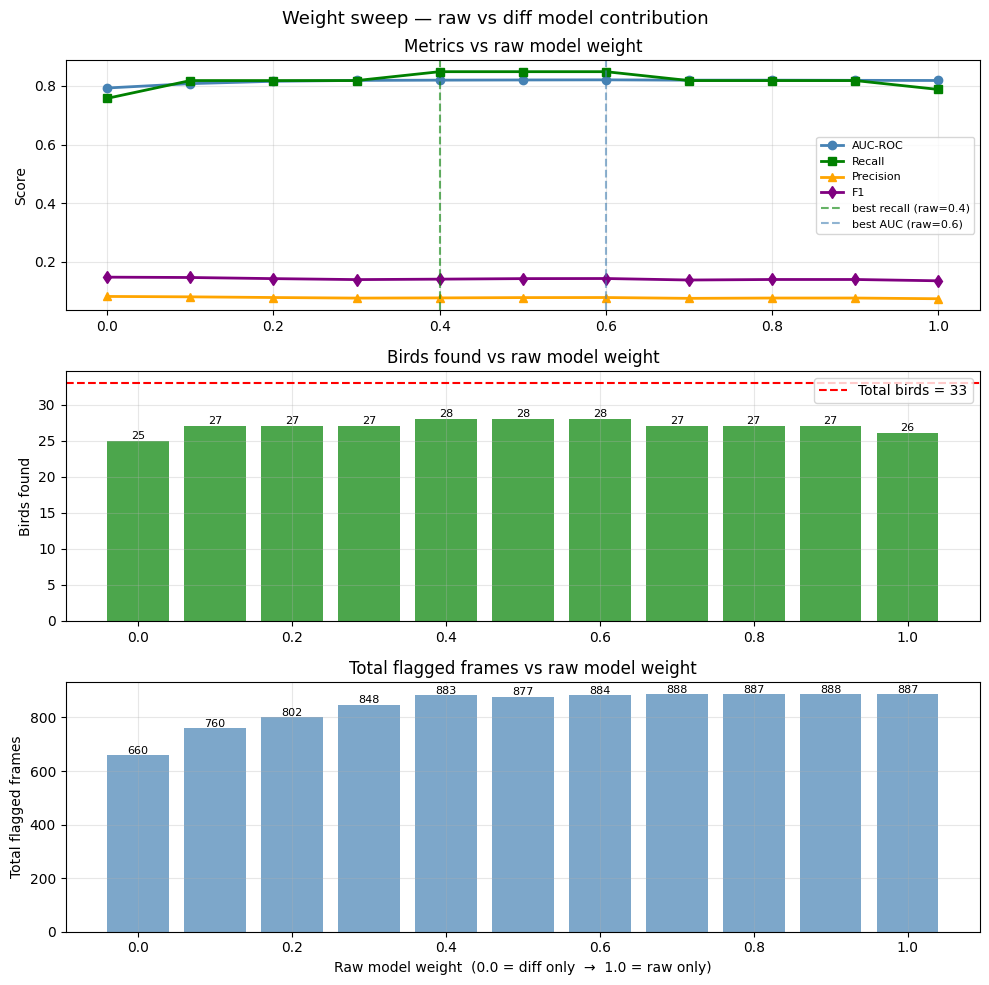


Plot saved to /Users/iris/Desktop/ETH/DAS Project/camera-trap-gan/outputs/dual_model_20260315_151948/weight_sweep.png


In [5]:
"""
Weight tuning script — loads saved models, no retraining needed.
Run this after dual_model_pipeline.py has already trained and saved models.
"""

import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.metrics import (roc_auc_score, precision_recall_fscore_support,
                             average_precision_score)
from tqdm import tqdm
import cv2

# ══════════════════════════════════════════════════════════════
# CONFIG — point to your saved models
# ══════════════════════════════════════════════════════════════
FRAMES_FOLDER  = "/Users/iris/Desktop/ETH/DAS Project/camera-trap-gan/data/frames/FH102_02"
CSV_PATH       = "/Users/iris/Desktop/ETH/DAS Project/camera-trap-gan/data/Weinstein2018MEE_ground_truth.csv"
VIDEO_NAME     = "FH102_02"

# ← point to your saved run folder
SAVED_RUN      = "/Users/iris/Desktop/ETH/DAS Project/camera-trap-gan/outputs/dual_model_20260315_151948"
MODEL_A_PATH   = f"{SAVED_RUN}/model_A_raw_final.pth"
MODEL_B_PATH   = f"{SAVED_RUN}/model_B_diff_final.pth"

IMG_SIZE       = 256
BATCH_SIZE     = 32
LATENT_DIM     = 256
THRESHOLD_STD  = 2
SMOOTH_WINDOW  = 2
# ══════════════════════════════════════════════════════════════


# ── paste your existing Dataset and Autoencoder classes here ──
# (same as dual_model_pipeline.py — copy them in)

class CameraTrapDataset(Dataset):
    def __init__(self, frames_folder, img_size=256, use_diff=False):
        self.use_diff    = use_diff
        self.frame_paths = sorted([
            os.path.join(frames_folder, f)
            for f in os.listdir(frames_folder)
            if f.endswith('.jpg')
        ])
        self.transform = transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])
        ])
        print(f"Dataset: {len(self.frame_paths)} frames  "
              f"[{'diff' if use_diff else 'raw'} mode]")

    def __len__(self): return len(self.frame_paths)

    def __getitem__(self, idx):
        if self.use_diff and idx > 0:
            curr = cv2.cvtColor(cv2.imread(self.frame_paths[idx]),   cv2.COLOR_BGR2RGB)
            prev = cv2.cvtColor(cv2.imread(self.frame_paths[idx-1]), cv2.COLOR_BGR2RGB)
            img  = cv2.absdiff(curr, prev)
        else:
            img = cv2.cvtColor(cv2.imread(self.frame_paths[idx]), cv2.COLOR_BGR2RGB)
        return self.transform(img), self.frame_paths[idx]


class Autoencoder(nn.Module):
    def __init__(self, latent_dim=256):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3,64,4,2,1), nn.ReLU(),
            nn.Conv2d(64,128,4,2,1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128,256,4,2,1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.Conv2d(256,512,4,2,1), nn.BatchNorm2d(512), nn.ReLU(),
            nn.Flatten(), nn.Linear(512*16*16, latent_dim)
        )
        self.decoder_fc = nn.Linear(latent_dim, 512*16*16)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(512,256,4,2,1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.ConvTranspose2d(256,128,4,2,1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.ConvTranspose2d(128,64,4,2,1),  nn.BatchNorm2d(64),  nn.ReLU(),
            nn.ConvTranspose2d(64,3,4,2,1), nn.Tanh()
        )

    def forward(self, x):
        z = self.encoder(x)
        x = self.decoder_fc(z)
        return self.decoder(x.view(-1,512,16,16))

    def anomaly_score(self, x):
        return torch.mean((x - self.forward(x))**2, dim=[1,2,3])


def score_frames(model, dataset, device, desc="Scoring"):
    loader     = DataLoader(dataset, batch_size=BATCH_SIZE,
                            shuffle=False, num_workers=0)
    all_scores = []
    all_paths  = []
    model.eval()
    with torch.no_grad():
        for frames, paths in tqdm(loader, desc=f"  {desc}"):
            frames = frames.to(device)
            all_scores.extend(model.anomaly_score(frames).cpu().numpy())
            all_paths.extend(paths)
    return np.array(all_scores), all_paths


def smooth_max(scores, window=2):
    smoothed = np.zeros_like(scores)
    for i in range(len(scores)):
        smoothed[i] = np.max(scores[max(0,i-window):min(len(scores),i+window+1)])
    return smoothed


def normalise(scores):
    return (scores - scores.min()) / (scores.max() - scores.min() + 1e-8)


# ══════════════════════════════════════════════════════════════
# MAIN
# ══════════════════════════════════════════════════════════════

device = torch.device(
    "mps"  if torch.backends.mps.is_available() else
    "cuda" if torch.cuda.is_available() else "cpu"
)
print(f"Device: {device}")

# ── Step 1: load ground truth ─────────────────────────────────
df       = pd.read_csv(CSV_PATH)
df_video = df[df['Video'] == VIDEO_NAME]
positive_frames = set(f"frame_{(r['Frame']-1):05d}.jpg"
                      for _, r in df_video.iterrows() if r['Truth']=='Positive')
negative_frames = set(f"frame_{(r['Frame']-1):05d}.jpg"
                      for _, r in df_video.iterrows() if r['Truth']=='Negative')
print(f"Birds: {len(positive_frames)}  Normal: {len(negative_frames)}")

# ── Step 2: load saved models ─────────────────────────────────
print(f"\nLoading saved models...")

model_A = Autoencoder(latent_dim=LATENT_DIM).to(device)
model_A.load_state_dict(torch.load(MODEL_A_PATH, map_location=device))
model_A.eval()
print(f"  ✓ Model A loaded: {MODEL_A_PATH}")

model_B = Autoencoder(latent_dim=LATENT_DIM).to(device)
model_B.load_state_dict(torch.load(MODEL_B_PATH, map_location=device))
model_B.eval()
print(f"  ✓ Model B loaded: {MODEL_B_PATH}")

# ── Step 3: score all frames ──────────────────────────────────
print(f"\nScoring all frames...")
dataset_raw  = CameraTrapDataset(FRAMES_FOLDER, IMG_SIZE, use_diff=False)
dataset_diff = CameraTrapDataset(FRAMES_FOLDER, IMG_SIZE, use_diff=True)

scores_raw,  all_paths = score_frames(model_A, dataset_raw,  device, "Model A (raw)")
scores_diff, _         = score_frames(model_B, dataset_diff, device, "Model B (diff)")

# smooth + normalise
scores_diff_smooth = smooth_max(scores_diff, window=SMOOTH_WINDOW)
scores_raw_norm    = normalise(scores_raw)
scores_diff_norm   = normalise(scores_diff_smooth)

print(f"Scoring done!")

# ── Step 4: build labelled index ──────────────────────────────
labelled_indices = []
y_true_labelled  = []

for i, path in enumerate(all_paths):
    filename = os.path.basename(path)
    if filename in positive_frames:
        labelled_indices.append(i)
        y_true_labelled.append(1)
    elif filename in negative_frames:
        labelled_indices.append(i)
        y_true_labelled.append(0)

y_true_labelled = np.array(y_true_labelled)

# ── Step 5: weight sweep ──────────────────────────────────────
print(f"\n{'='*72}")
print(f"  WEIGHT SWEEP")
print(f"{'='*72}")
print(f"{'Raw':>6} {'Diff':>6} {'AUC':>8} {'Prec':>8} "
      f"{'Recall':>8} {'F1':>8} {'Flagged':>8} {'Birds':>6}")
print("-" * 66)

results_grid      = []
best_auc          = 0
best_recall       = 0
best_f1           = 0
best_auc_combo    = None
best_recall_combo = None
best_f1_combo     = None

for w_raw in np.arange(0.0, 1.05, 0.1):
    w_diff = round(1.0 - w_raw, 1)

    scores_combo    = w_raw * scores_raw_norm + w_diff * scores_diff_norm
    threshold_combo = scores_combo.mean() + THRESHOLD_STD * scores_combo.std()
    scores_lab      = np.array([scores_combo[i] for i in labelled_indices])
    y_pred_combo    = (scores_lab > threshold_combo).astype(int)

    p, r, f, _ = precision_recall_fscore_support(
        y_true_labelled, y_pred_combo, average='binary', zero_division=0)
    auc = roc_auc_score(y_true_labelled, scores_lab)

    total_flagged = int((scores_combo > threshold_combo).sum())
    birds_found   = int(y_true_labelled[y_pred_combo == 1].sum())

    if auc > best_auc:
        best_auc = auc
        best_auc_combo = (w_raw, w_diff, scores_combo.copy(), threshold_combo)
    if r > best_recall:
        best_recall = r
        best_recall_combo = (w_raw, w_diff, scores_combo.copy(), threshold_combo)
    if f > best_f1:
        best_f1 = f
        best_f1_combo = (w_raw, w_diff, scores_combo.copy(), threshold_combo)

    markers = []
    if auc >= best_auc:    markers.append("AUC")
    if r   >= best_recall: markers.append("Recall")
    if f   >= best_f1:     markers.append("F1")
    marker = f"  ← best {'+'.join(markers)}" if markers else ""

    print(f"{w_raw:>6.1f} {w_diff:>6.1f} {auc:>8.3f} "
          f"{p:>8.3f} {r:>8.3f} {f:>8.3f} "
          f"{total_flagged:>8,} {birds_found:>6}{marker}")

    results_grid.append({
        'w_raw': w_raw, 'w_diff': w_diff, 'auc': auc,
        'precision': p, 'recall': r, 'f1': f,
        'total_flagged': total_flagged, 'birds_found': birds_found,
        'scores': scores_combo.copy(), 'threshold': threshold_combo
    })

print(f"\n{'='*72}")
print(f"  BEST CONFIGURATIONS")
print(f"{'='*72}")
print(f"  Best AUC    : raw={best_auc_combo[0]:.1f}  "
      f"diff={best_auc_combo[1]:.1f}  AUC={best_auc:.3f}")
print(f"  Best Recall : raw={best_recall_combo[0]:.1f}  "
      f"diff={best_recall_combo[1]:.1f}  Recall={best_recall:.3f}")
print(f"  Best F1     : raw={best_f1_combo[0]:.1f}  "
      f"diff={best_f1_combo[1]:.1f}  F1={best_f1:.3f}")
print(f"{'='*72}")

# ── Step 6: plot weight sweep ─────────────────────────────────
w_raws  = [r['w_raw']        for r in results_grid]
aucs    = [r['auc']          for r in results_grid]
recalls = [r['recall']       for r in results_grid]
precs   = [r['precision']    for r in results_grid]
f1s     = [r['f1']           for r in results_grid]
flagged = [r['total_flagged'] for r in results_grid]
birds   = [r['birds_found']   for r in results_grid]

fig, axes = plt.subplots(3, 1, figsize=(10, 10))
fig.suptitle("Weight sweep — raw vs diff model contribution", fontsize=13)

axes[0].plot(w_raws, aucs,    'o-', color='steelblue', lw=2, label='AUC-ROC')
axes[0].plot(w_raws, recalls, 's-', color='green',     lw=2, label='Recall')
axes[0].plot(w_raws, precs,   '^-', color='orange',    lw=2, label='Precision')
axes[0].plot(w_raws, f1s,     'd-', color='purple',    lw=2, label='F1')
axes[0].axvline(x=best_recall_combo[0], color='green',
                ls='--', alpha=0.6, label=f'best recall (raw={best_recall_combo[0]:.1f})')
axes[0].axvline(x=best_auc_combo[0],    color='steelblue',
                ls='--', alpha=0.6, label=f'best AUC (raw={best_auc_combo[0]:.1f})')
axes[0].set_ylabel("Score")
axes[0].set_title("Metrics vs raw model weight")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

axes[1].bar(w_raws, birds, width=0.08, color='green', alpha=0.7)
axes[1].axhline(y=33, color='red', ls='--', lw=1.5,
                label='Total birds = 33')
for x, b in zip(w_raws, birds):
    axes[1].text(x, b+0.3, str(b), ha='center', fontsize=8)
axes[1].set_ylabel("Birds found")
axes[1].set_title("Birds found vs raw model weight")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].bar(w_raws, flagged, width=0.08, color='steelblue', alpha=0.7)
for x, fl in zip(w_raws, flagged):
    axes[2].text(x, fl+5, str(fl), ha='center', fontsize=8)
axes[2].set_ylabel("Total flagged frames")
axes[2].set_xlabel("Raw model weight  (0.0 = diff only  →  1.0 = raw only)")
axes[2].set_title("Total flagged frames vs raw model weight")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(SAVED_RUN, "weight_sweep.png"), dpi=150)
plt.show()
print(f"\nPlot saved to {SAVED_RUN}/weight_sweep.png")